# Proyecto de regresion: prediccion de ventas globales de videojuegos

## 3.1 Comprension del negocio

### Introduccion al problema
El dataset contiene informacion comercial y de recepcion critica de videojuegos publicados en distintas plataformas. Incluye genero, plataforma, publicador, desarrollador, clasificacion, ventas regionales observadas y puntajes de critica y usuarios.

El fenomeno estudiado es el desempeno comercial global de un videojuego. Analizarlo es util porque las ventas no dependen solo del genero o plataforma, tambien influyen la recepcion del publico, la critica y la presencia regional.

El problema consiste en estimar `Global_Sales`, es decir, las ventas globales en millones de copias. El modelo no busca adivinar ventas antes de existir informacion del juego; estima ventas globales usando datos disponibles del videojuego y ventas regionales observadas.

### Objetivo de la prediccion
La variable a predecir es `Global_Sales`. Sus valores son numericos continuos y representan millones de copias vendidas a nivel global. Por eso se trata de una tarea de regresion.

Predecir esta variable puede apoyar decisiones de planeacion, inventario, distribucion y analisis comercial.

### Aplicacion del modelo
Un analista de una publicadora o tienda digital podria usar el modelo para estimar el alcance global de un juego con base en sus caracteristicas y ventas tempranas en regiones principales. Una prediccion incorrecta podria generar malas decisiones de inventario o expectativas comerciales poco realistas.


## 3.2 Comprension de los datos

En esta etapa se revisa el dataset antes de transformarlo. Se analizan dimensiones, atributos, calidad y patrones exploratorios.


In [1]:
# Importacion de librerias principales
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


### Carga del dataset

El dataset se carga desde GitHub Raw. Se deja un respaldo local para evitar errores si no hay conexion o si el archivo aun no esta disponible en GitHub.


In [2]:
# URL del archivo CSV en GitHub en formato RAW
DATASET_NAME = 'Video Games Sales as at 22 Dec 2016'
DATASET_SOURCE = 'Kaggle: Video Games Sales as at 22 Dec 2016; GitHub Raw'
DATASET_URL = 'https://raw.githubusercontent.com/JoadanMatias10/videogames/main/Video_Games_Sales_as_at_22_Dec_2016.csv'

# Cargar el dataset desde GitHub Raw
dataset_raw = pd.read_csv(DATASET_URL, encoding='latin1', na_values=['N/A', ''], keep_default_na=True)

dataset = dataset_raw.copy()

numeric_columns = [
    'Year_of_Release', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
    'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count'
]
for column in numeric_columns:
    if column in dataset.columns:
        dataset[column] = pd.to_numeric(dataset[column], errors='coerce')

print(f'Fuente usada: GitHub Raw')
print(f'Filas y columnas: {dataset.shape}')
dataset.head()


Fuente usada: GitHub Raw
Filas y columnas: (16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Dimensiones originales solicitadas
dataset.shape


(16719, 16)

In [4]:
target = 'Global_Sales'
identifier_cols = ['Name']
regional_total_components = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

useful_predictors = [col for col in dataset.columns if col not in identifier_cols + [target]]

general_description = pd.DataFrame({
    'Elemento': [
        'Nombre del dataset',
        'Fuente',
        'URL',
        'Registros originales',
        'Columnas originales',
        'Variables independientes utiles',
        'Variable dependiente',
        'Contenido general'
    ],
    'Valor': [
        DATASET_NAME,
        DATASET_SOURCE,
        DATASET_URL,
        dataset.shape[0],
        dataset.shape[1],
        len(useful_predictors),
        target,
        'Videojuegos, plataforma, genero, publicador, ventas, puntajes y clasificacion.'
    ]
})
general_description


,Elemento,Valor
0,Nombre del dataset,Video Games Sales as at 22 Dec 2016
1,Fuente,Kaggle: Video Games Sales as at 22 Dec 2016; G...
2,URL,https://raw.githubusercontent.com/JoadanMatias...
3,Registros originales,16719
4,Columnas originales,16
5,Variables independientes utiles,14
6,Variable dependiente,Global_Sales
7,Contenido general,"Videojuegos, plataforma, genero, publicador, v..."


**Interpretacion:** el dataset supera 600 registros y tiene mas de 8 variables predictoras utiles. `Name` se considera identificador y no cuenta como predictora.


### Descripcion de atributos

La tabla resume los atributos originales, su tipo conceptual, dato en Python y porcentaje de nulos.


In [5]:
attribute_info = {
    'Name': ('Nombre del videojuego.', 'Nominal / identificador'),
    'Platform': ('Consola o plataforma de lanzamiento.', 'Nominal'),
    'Year_of_Release': ('Anio de lanzamiento.', 'Discreto'),
    'Genre': ('Genero principal del videojuego.', 'Nominal'),
    'Publisher': ('Empresa publicadora.', 'Nominal'),
    'NA_Sales': ('Ventas en Norteamerica, en millones.', 'Continuo'),
    'EU_Sales': ('Ventas en Europa, en millones.', 'Continuo'),
    'JP_Sales': ('Ventas en Japon, en millones.', 'Continuo'),
    'Other_Sales': ('Ventas en otras regiones, en millones.', 'Continuo'),
    'Global_Sales': ('Ventas globales, en millones.', 'Continuo'),
    'Critic_Score': ('Puntaje promedio de critica.', 'Continuo'),
    'Critic_Count': ('Cantidad de resenias de critica.', 'Discreto'),
    'User_Score': ('Puntaje promedio de usuarios.', 'Continuo'),
    'User_Count': ('Cantidad de resenias de usuarios.', 'Discreto'),
    'Developer': ('Empresa desarrolladora.', 'Nominal'),
    'Rating': ('Clasificacion de contenido.', 'Nominal')
}

attribute_table = pd.DataFrame([
    {
        'Atributo': column,
        'Descripcion': attribute_info.get(column, ('Sin descripcion', 'No definido'))[0],
        'Tipo de atributo': attribute_info.get(column, ('Sin descripcion', 'No definido'))[1],
        'Tipo Python': str(dataset[column].dtype),
        'Nulos': int(dataset[column].isna().sum()),
        '% nulos': round(dataset[column].isna().mean() * 100, 2)
    }
    for column in dataset.columns
])
attribute_table


,Atributo,Descripcion,Tipo de atributo,Tipo Python,Nulos,% nulos
0,Name,Nombre del videojuego.,Nominal / identificador,str,2,0.01
1,Platform,Consola o plataforma de lanzamiento.,Nominal,str,0,0.00
2,Year_of_Release,Anio de lanzamiento.,Discreto,float64,269,1.61
3,Genre,Genero principal del videojuego.,Nominal,str,2,0.01
4,Publisher,Empresa publicadora.,Nominal,str,54,0.32
5,NA_Sales,"Ventas en Norteamerica, en millones.",Continuo,float64,0,0.00
6,EU_Sales,"Ventas en Europa, en millones.",Continuo,float64,0,0.00
7,JP_Sales,"Ventas en Japon, en millones.",Continuo,float64,0,0.00
8,Other_Sales,"Ventas en otras regiones, en millones.",Continuo,float64,0,0.00
9,Global_Sales,"Ventas globales, en millones.",Continuo,float64,0,0.00


**Interpretacion:** el dataset combina variables categoricas, numericas discretas y numericas continuas. La variable objetivo es continua.


### Calidad de los datos

Se revisan duplicados, nulos, valores invalidos, atipicos, columnas constantes, identificadores y posibles fugas de datos.


In [6]:
sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', target]
score_columns = ['Critic_Score', 'User_Score']
count_columns = ['Critic_Count', 'User_Count']

duplicated_rows = int(dataset.duplicated().sum())
missing_cells = int(dataset.isna().sum().sum())
invalid_years = int((dataset['Year_of_Release'].notna() & ~dataset['Year_of_Release'].between(1970, 2026)).sum())
negative_sales = int((dataset[sales_columns] < 0).sum().sum())
invalid_scores = int(
    ((dataset['Critic_Score'].notna()) & ~dataset['Critic_Score'].between(0, 100)).sum()
    + ((dataset['User_Score'].notna()) & ~dataset['User_Score'].between(0, 10)).sum()
)
constant_columns = [col for col in dataset.columns if dataset[col].nunique(dropna=True) <= 1]
low_variability_columns = [col for col in dataset.columns if dataset[col].nunique(dropna=True) <= 2]
high_outliers = int((dataset[target] > dataset[target].quantile(0.99)).sum())

quality_report = pd.DataFrame({
    'Aspecto': [
        'Duplicados',
        'Valores nulos',
        'Anios invalidos',
        'Ventas negativas',
        'Puntajes fuera de rango',
        'Atipicos altos en Global_Sales',
        'Columnas constantes',
        'Columnas con poca variabilidad',
        'Identificador sin utilidad predictiva',
        'Riesgo de fuga de datos'
    ],
    'Resultado': [
        duplicated_rows,
        missing_cells,
        invalid_years,
        negative_sales,
        invalid_scores,
        high_outliers,
        ', '.join(constant_columns) if constant_columns else 'No hay',
        ', '.join(low_variability_columns) if low_variability_columns else 'No hay',
        'Name',
        'Las ventas regionales se usan porque el alcance del modelo es estimar ventas globales con informacion comercial observada.'
    ],
    'Efecto posible': [
        'Pueden sesgar el entrenamiento si se repiten casos.',
        'Pueden reducir datos utiles o introducir sesgo si se eliminan sin criterio.',
        'Afectan la relacion temporal con las ventas.',
        'Serian inconsistentes con el significado de ventas.',
        'Distorsionan la escala de recepcion critica.',
        'Pueden aumentar errores en juegos muy exitosos.',
        'No aportan informacion al modelo.',
        'Aportan poca separacion entre registros.',
        'Puede memorizar titulos en vez de aprender patrones.',
        'Usar todas las ventas regionales permite reconstruir casi directamente Global_Sales.'
    ]
})
quality_report


,Aspecto,Resultado,Efecto posible
0,Duplicados,0,Pueden sesgar el entrenamiento si se repiten c...
1,Valores nulos,49141,Pueden reducir datos utiles o introducir sesgo...
2,Anios invalidos,0,Afectan la relacion temporal con las ventas.
3,Ventas negativas,0,Serian inconsistentes con el significado de ve...
4,Puntajes fuera de rango,0,Distorsionan la escala de recepcion critica.
5,Atipicos altos en Global_Sales,168,Pueden aumentar errores en juegos muy exitosos.
6,Columnas constantes,No hay,No aportan informacion al modelo.
7,Columnas con poca variabilidad,No hay,Aportan poca separacion entre registros.
8,Identificador sin utilidad predictiva,Name,Puede memorizar titulos en vez de aprender pat...
9,Riesgo de fuga de datos,Las ventas regionales se usan porque el alcanc...,Usar todas las ventas regionales permite recon...


In [7]:
# Columnas con valores faltantes
missing_table = pd.DataFrame({
    'Nulos': dataset.isna().sum(),
    '% nulos': (dataset.isna().mean() * 100).round(2)
}).query('Nulos > 0').sort_values('% nulos', ascending=False)
missing_table


,Nulos,% nulos
User_Score,9129,54.60
User_Count,9129,54.60
Critic_Count,8582,51.33
Critic_Score,8582,51.33
Rating,6769,40.49
Developer,6623,39.61
Year_of_Release,269,1.61
Publisher,54,0.32
Name,2,0.01
Genre,2,0.01


**Interpretacion:** hay nulos relevantes en puntajes, conteos, desarrollador y clasificacion. Se trataran con imputacion dentro de pipelines para evitar fuga de informacion.


### Analisis exploratorio de datos

Se revisan estadisticas, distribuciones y relaciones con la variable objetivo.


In [8]:
# Estadisticas descriptivas generales
dataset.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,16717,11562,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,16719,31,PS2,2161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Release,16450.0,NaN,NaN,NaN,2006.487356,5.878995,1980.0,2003.0,2007.0,2010.0,2020.0
Genre,16717,12,Action,3370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,16665,582,Electronic Arts,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_Sales,16719.0,NaN,NaN,NaN,0.26333,0.813514,0.0,0.0,0.08,0.24,41.36
EU_Sales,16719.0,NaN,NaN,NaN,0.145025,0.503283,0.0,0.0,0.02,0.11,28.96
JP_Sales,16719.0,NaN,NaN,NaN,0.077602,0.308818,0.0,0.0,0.0,0.04,10.22
Other_Sales,16719.0,NaN,NaN,NaN,0.047332,0.18671,0.0,0.0,0.01,0.03,10.57
Global_Sales,16719.0,NaN,NaN,NaN,0.533543,1.547935,0.01,0.06,0.17,0.47,82.53


In [9]:
# Estadisticas numericas con percentiles
dataset[numeric_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Year_of_Release,16450.0,2006.487356,5.878995,1980.00,1987.00,1996.00,2003.00,2007.00,2010.00,2015.00,2016.0000,2020.00
NA_Sales,16719.0,0.263330,0.813514,0.00,0.00,0.00,0.00,0.08,0.24,1.06,2.7900,41.36
EU_Sales,16719.0,0.145025,0.503283,0.00,0.00,0.00,0.00,0.02,0.11,0.62,1.9382,28.96
JP_Sales,16719.0,0.077602,0.308818,0.00,0.00,0.00,0.00,0.00,0.04,0.36,1.2682,10.22
Other_Sales,16719.0,0.047332,0.186710,0.00,0.00,0.00,0.00,0.01,0.03,0.20,0.6300,10.57
Global_Sales,16719.0,0.533543,1.547935,0.01,0.01,0.02,0.06,0.17,0.47,2.04,5.4582,82.53
Critic_Score,8137.0,68.967679,13.938165,13.00,31.00,43.00,60.00,71.00,79.00,89.00,94.0000,98.00
Critic_Count,8137.0,26.360821,18.980495,3.00,4.00,5.00,12.00,21.00,36.00,65.00,84.0000,113.00
User_Score,7590.0,7.125046,1.500006,0.00,2.30,4.10,6.40,7.50,8.20,8.90,9.2000,9.70
User_Count,7590.0,162.229908,561.282326,4.00,4.00,5.00,10.00,24.00,81.00,724.55,2527.3300,10665.00


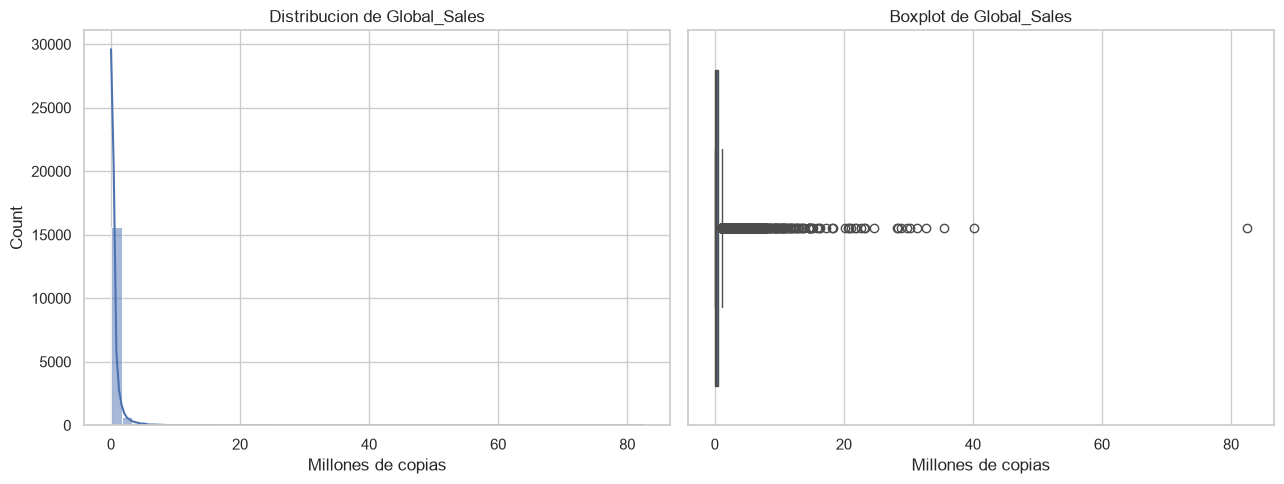

In [10]:
# Distribucion de Global_Sales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(dataset[target], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribucion de Global_Sales')
axes[0].set_xlabel('Millones de copias')
sns.boxplot(x=dataset[target], ax=axes[1])
axes[1].set_title('Boxplot de Global_Sales')
axes[1].set_xlabel('Millones de copias')
plt.tight_layout()
plt.show()


**Interpretacion:** `Global_Sales` esta sesgada a la derecha. La mayoria de juegos vende poco y pocos titulos concentran ventas muy altas.


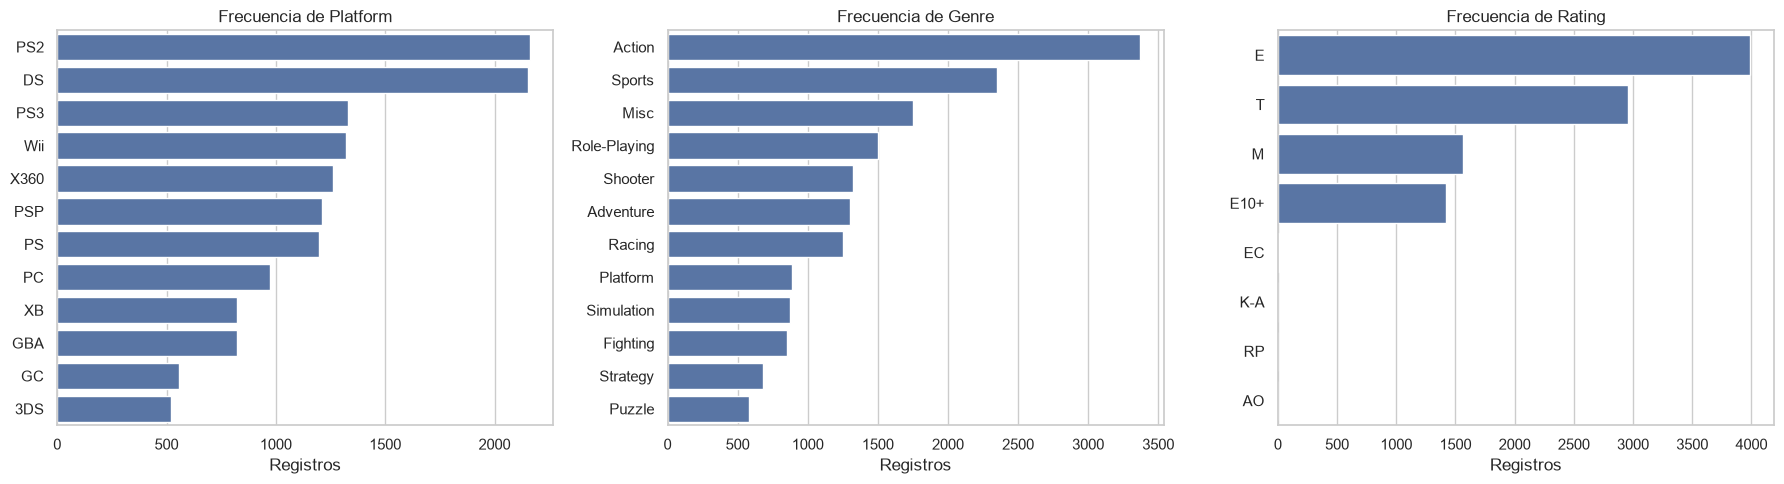

In [11]:
# Variables categoricas principales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ['Platform', 'Genre', 'Rating']):
    order = dataset[column].value_counts().head(12).index
    sns.countplot(data=dataset, y=column, order=order, ax=ax)
    ax.set_title(f'Frecuencia de {column}')
    ax.set_xlabel('Registros')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


**Interpretacion:** hay concentracion en ciertas plataformas, generos y clasificaciones. Estas categorias pueden aportar senales utiles al modelo.


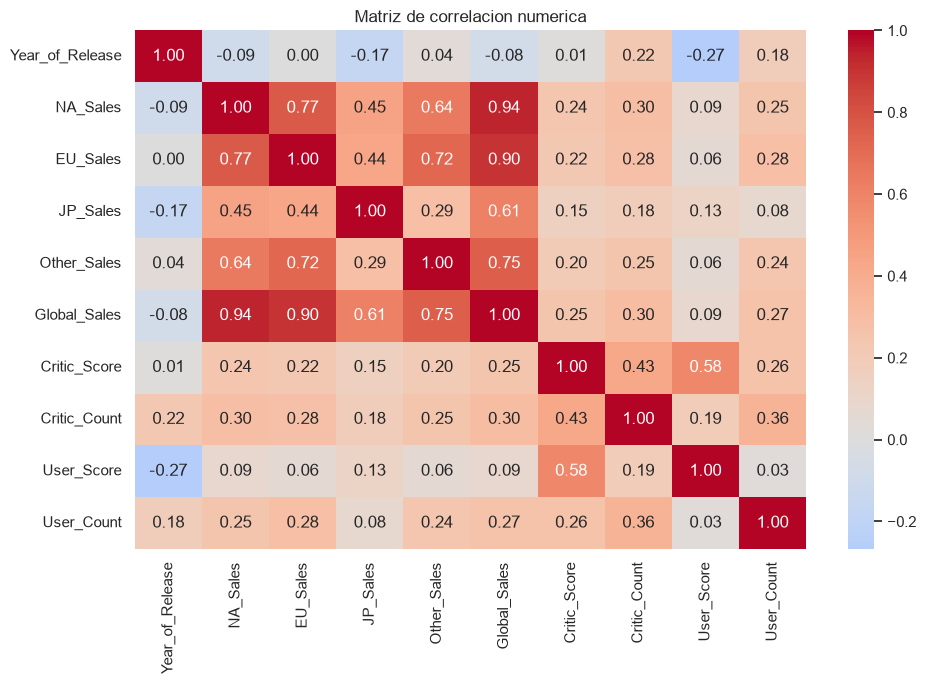

In [12]:
# Matriz de correlacion numerica
corr_matrix = dataset[numeric_columns].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion numerica')
plt.tight_layout()
plt.show()


**Interpretacion:** las ventas regionales observadas se relacionan con `Global_Sales`. Los puntajes y conteos muestran relacion menor, por eso se combinan con otros metodos de seleccion.


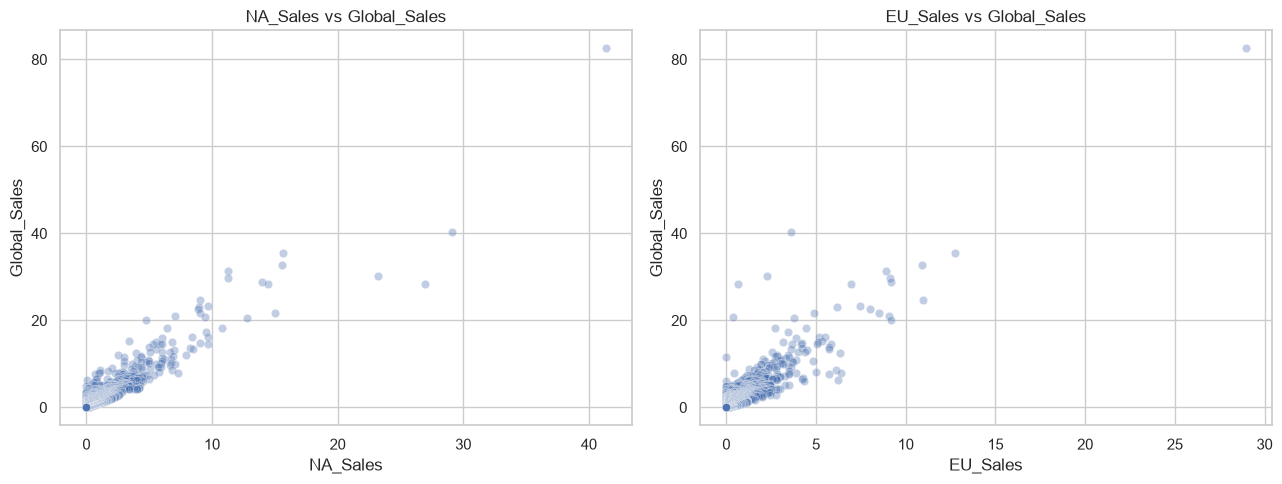

In [13]:
# Relaciones de ventas regionales con Global_Sales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=dataset, x='NA_Sales', y=target, alpha=0.35, ax=axes[0])
axes[0].set_title('NA_Sales vs Global_Sales')
sns.scatterplot(data=dataset, x='EU_Sales', y=target, alpha=0.35, ax=axes[1])
axes[1].set_title('EU_Sales vs Global_Sales')
plt.tight_layout()
plt.show()


**Interpretacion:** las ventas regionales tienen relacion positiva fuerte con ventas globales. El modelo se interpreta como estimacion con informacion comercial observada.


## 3.3 Preparacion de los datos

Se definen `X` y `y`, se tratan nulos, se codifican categorias y se escala dentro de pipelines.


In [14]:
model_data = dataset.drop_duplicates().copy()
model_data = model_data.dropna(subset=[target]).copy()

# Reglas simples de calidad: valores invalidos se vuelven nulos para imputacion.
model_data.loc[model_data['Year_of_Release'].notna() & ~model_data['Year_of_Release'].between(1970, 2026), 'Year_of_Release'] = np.nan
model_data.loc[model_data['Critic_Score'].notna() & ~model_data['Critic_Score'].between(0, 100), 'Critic_Score'] = np.nan
model_data.loc[model_data['User_Score'].notna() & ~model_data['User_Score'].between(0, 10), 'User_Score'] = np.nan
for column in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Count', 'User_Count']:
    model_data.loc[model_data[column] < 0, column] = np.nan

model_features = [
    'Platform', 'Year_of_Release', 'Genre', 'Publisher',
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
    'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count',
    'Developer', 'Rating'
]

X = model_data[model_features].copy()
y = model_data[target].copy()

excluded_table = pd.DataFrame({
    'Columna eliminada': ['Name'],
    'Justificacion': [
        'Es nombre del videojuego e identificador textual.'
    ]
})

pd.DataFrame({
    'Elemento': ['Registros utiles', 'Variables en X', 'Variable y', 'Tipo de problema'],
    'Valor': [X.shape[0], X.shape[1], target, 'Regresion']
})


,Elemento,Valor
0,Registros utiles,16719
1,Variables en X,14
2,Variable y,Global_Sales
3,Tipo de problema,Regresion


In [15]:
excluded_table


,Columna eliminada,Justificacion
0,Name,Es nombre del videojuego e identificador textual.


**Justificacion:** `Global_Sales` es continua porque mide millones de copias vendidas. `Name` no se usa por ser identificador. Las ventas regionales se conservan porque el modelo estima ventas globales con informacion comercial observada.


In [16]:
# Nulos en las variables independientes
missing_X = pd.DataFrame({
    'Nulos': X.isna().sum(),
    '% nulos': (X.isna().mean() * 100).round(2)
}).sort_values('% nulos', ascending=False)
missing_X


,Nulos,% nulos
User_Score,9129,54.60
User_Count,9129,54.60
Critic_Score,8582,51.33
Critic_Count,8582,51.33
Rating,6769,40.49
Developer,6623,39.61
Year_of_Release,269,1.61
Publisher,54,0.32
Genre,2,0.01
Platform,0,0.00


**Tratamiento de nulos:** se imputan numericas con mediana y categoricas con moda. No se generan nulos artificiales porque el dataset ya contiene valores faltantes reales.


In [17]:
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = [col for col in model_features if col not in categorical_features]

preparation_summary = pd.DataFrame({
    'Tipo': ['Numericas', 'Categoricas'],
    'Columnas': [', '.join(numeric_features), ', '.join(categorical_features)],
    'Tratamiento': [
        'Imputacion con mediana y escalado StandardScaler.',
        'Imputacion con moda y OneHotEncoder.'
    ]
})
preparation_summary


,Tipo,Columnas,Tratamiento
0,Numericas,"Year_of_Release, NA_Sales, EU_Sales, JP_Sales,...",Imputacion con mediana y escalado StandardScaler.
1,Categoricas,"Platform, Genre, Publisher, Developer, Rating",Imputacion con moda y OneHotEncoder.


In [18]:
def make_preprocessor(features):
    cat_cols = X[features].select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = [col for col in features if col not in cat_cols]
    
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=30,
            sparse_output=False
        ))
    ])
    
    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, num_cols),
            ('cat', categorical_pipe, cat_cols)
        ],
        verbose_feature_names_out=False
    )

preprocessor_all = make_preprocessor(model_features)
encoded_preview = preprocessor_all.fit_transform(X)
encoded_feature_count = encoded_preview.shape[1]

pd.DataFrame({
    'Concepto': ['Columnas originales en X', 'Columnas despues de OneHotEncoder'],
    'Cantidad': [len(model_features), encoded_feature_count]
})


,Concepto,Cantidad
0,Columnas originales en X,14
1,Columnas despues de OneHotEncoder,168


**Escalado:** se usa `StandardScaler` despues de imputar y codificar. Es necesario para Ridge, MLP y PCA. En arboles no es indispensable, pero mantenerlo en el pipeline permite condiciones equivalentes.


## 3.4 Seleccion y transformacion de caracteristicas

Se construyen dos representaciones: caracteristicas seleccionadas y componentes principales.


### Escenario 1: caracteristicas seleccionadas

La seleccion final considera correlacion, RFE e importancia mediante arboles.


In [19]:
# Correlacion con y para variables numericas
corr_with_target = (
    model_data[numeric_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

correlation_table = corr_with_target.reset_index()
correlation_table.columns = ['Caracteristica', 'Correlacion con Global_Sales']
correlation_table


,Caracteristica,Correlacion con Global_Sales
0,NA_Sales,0.941010
1,EU_Sales,0.901239
2,Other_Sales,0.749242
3,JP_Sales,0.612300
4,Critic_Count,0.303571
5,User_Count,0.265012
6,Critic_Score,0.245471
7,User_Score,0.088139
8,Year_of_Release,-0.076433


**Interpretacion:** la correlacion detecta relaciones lineales. No evalua bien variables categoricas ni relaciones no lineales, por eso no se usa como unico criterio.


In [20]:
# RFE con Ridge sobre variables ya imputadas, codificadas y escaladas
selection_preprocessor = make_preprocessor(model_features)
X_encoded = selection_preprocessor.fit_transform(X)
encoded_feature_names = selection_preprocessor.get_feature_names_out()
X_encoded_scaled = StandardScaler().fit_transform(X_encoded)

rfe_estimator = Ridge(alpha=0.1)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=12)
rfe.fit(X_encoded_scaled, y)

rfe_table = pd.DataFrame({
    'Caracteristica transformada': encoded_feature_names,
    'Ranking RFE': rfe.ranking_,
    'Seleccionada por RFE': rfe.support_
}).sort_values(['Ranking RFE', 'Caracteristica transformada']).head(30)
rfe_table


,Caracteristica transformada,Ranking RFE,Seleccionada por RFE
6,Critic_Count,1,True
117,Developer_Blitz Games,1,True
2,EU_Sales,1,True
40,Genre_Role-Playing,1,True
3,JP_Sales,1,True
1,NA_Sales,1,True
4,Other_Sales,1,True
19,Platform_PS,1,True
20,Platform_PS2,1,True
21,Platform_PS3,1,True


**Interpretacion:** Ridge es compatible con RFE porque genera coeficientes. RFE elimina variables de forma recursiva y conserva las mas utiles para el estimador.


In [21]:
def original_feature_name(encoded_name):
    if encoded_name in model_features:
        return encoded_name
    for feature in model_features:
        if encoded_name.startswith(feature + '_'):
            return feature
    return encoded_name

rfe_full = pd.DataFrame({
    'Transformada': encoded_feature_names,
    'Original': [original_feature_name(name) for name in encoded_feature_names],
    'Ranking RFE': rfe.ranking_,
    'Seleccionada RFE': rfe.support_
})

rfe_by_original = (
    rfe_full.groupby('Original')
    .agg(
        RFE_selecciones=('Seleccionada RFE', 'sum'),
        Mejor_ranking_RFE=('Ranking RFE', 'min')
    )
    .reset_index()
)

tree_model = ExtraTreesRegressor(
    n_estimators=80,
    max_depth=14,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)
tree_model.fit(X_encoded_scaled, y)

tree_importance_full = pd.DataFrame({
    'Transformada': encoded_feature_names,
    'Original': [original_feature_name(name) for name in encoded_feature_names],
    'Importancia': tree_model.feature_importances_
})

tree_importance_original = (
    tree_importance_full.groupby('Original')['Importancia']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
tree_importance_original


,Original,Importancia
0,NA_Sales,0.436996
1,EU_Sales,0.311625
2,Other_Sales,0.101775
3,JP_Sales,0.092408
4,Publisher,0.019243
5,Platform,0.011530
6,Developer,0.010655
7,Genre,0.005190
8,Year_of_Release,0.004343
9,User_Count,0.001660


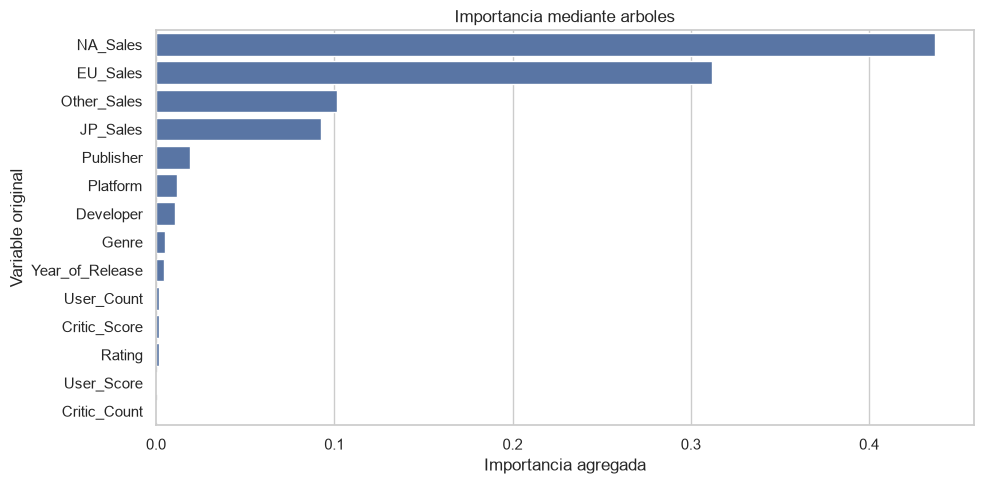

In [22]:
# Grafica de importancia agregada por variable original
plt.figure(figsize=(10, 5))
sns.barplot(data=tree_importance_original, x='Importancia', y='Original')
plt.title('Importancia mediante arboles')
plt.xlabel('Importancia agregada')
plt.ylabel('Variable original')
plt.tight_layout()
plt.show()


**Interpretacion:** los arboles capturan relaciones no lineales e interacciones. Su resultado se compara con RFE y correlacion para evitar una seleccion basada en un solo criterio.


In [23]:
selected_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score', 'Critic_Count']

comparison_table = pd.DataFrame({'Caracteristica': model_features})
comparison_table = comparison_table.merge(
    correlation_table.rename(columns={'Caracteristica': 'Caracteristica'}),
    on='Caracteristica',
    how='left'
)
comparison_table = comparison_table.merge(
    rfe_by_original,
    left_on='Caracteristica',
    right_on='Original',
    how='left'
).drop(columns=['Original'])
comparison_table = comparison_table.merge(
    tree_importance_original.rename(columns={'Original': 'Caracteristica', 'Importancia': 'Importancia arboles'}),
    on='Caracteristica',
    how='left'
)

comparison_table['Decision'] = np.where(
    comparison_table['Caracteristica'].isin(selected_features),
    'Incluir',
    'Excluir'
)
comparison_table['Resultado'] = np.where(
    comparison_table['Caracteristica'].isin(selected_features),
    'Seleccionada',
    'No seleccionada'
)
comparison_table = comparison_table.fillna({'Correlacion con Global_Sales': 'No aplica', 'RFE_selecciones': 0, 'Mejor_ranking_RFE': 'No aplica', 'Importancia arboles': 0})
comparison_table


,Caracteristica,Correlacion con Global_Sales,RFE_selecciones,Mejor_ranking_RFE,Importancia arboles,Decision,Resultado
0,Platform,No aplica,3,1,0.011530,Excluir,No seleccionada
1,Year_of_Release,-0.076433,0,49,0.004343,Excluir,No seleccionada
2,Genre,No aplica,1,1,0.005190,Excluir,No seleccionada
3,Publisher,No aplica,2,1,0.019243,Excluir,No seleccionada
4,NA_Sales,0.94101,1,1,0.436996,Incluir,Seleccionada
5,EU_Sales,0.901239,1,1,0.311625,Incluir,Seleccionada
6,JP_Sales,0.6123,1,1,0.092408,Incluir,Seleccionada
7,Other_Sales,0.749242,1,1,0.101775,Incluir,Seleccionada
8,Critic_Score,0.245471,0,110,0.001598,Incluir,Seleccionada
9,Critic_Count,0.303571,1,1,0.000707,Incluir,Seleccionada


**Seleccion final:** se usan seis variables: `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Critic_Score` y `Critic_Count`. Se incluyen porque combinan ventas regionales observadas y recepcion critica. Se excluyen variables de alta cardinalidad como `Developer` y `Publisher` para reducir ruido en el escenario seleccionado.


### Escenario 2: PCA

PCA se aplica despues de imputacion, codificacion y escalado. Usa las 12 variables definidas en `X`.


In [24]:
pca_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(model_features)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE))
])

X_pca = pca_pipeline.fit_transform(X)
pca_model = pca_pipeline.named_steps['pca']

pca_variance = pd.DataFrame({
    'Componente': range(1, pca_model.n_components_ + 1),
    'Varianza explicada': pca_model.explained_variance_ratio_,
    'Varianza acumulada': np.cumsum(pca_model.explained_variance_ratio_)
})

pd.DataFrame({
    'Concepto': [
        'Variables originales antes de PCA',
        'Variables transformadas antes de PCA',
        'Componentes conservados',
        'Varianza acumulada conservada'
    ],
    'Valor': [
        len(model_features),
        encoded_feature_count,
        pca_model.n_components_,
        round(pca_variance['Varianza acumulada'].iloc[-1], 4)
    ]
})


,Concepto,Valor
0,Variables originales antes de PCA,14.000
1,Variables transformadas antes de PCA,168.000
2,Componentes conservados,143.000
3,Varianza acumulada conservada,0.951


In [25]:
pca_variance.head(15)


,Componente,Varianza explicada,Varianza acumulada
0,1,0.023817,0.023817
1,2,0.020239,0.044057
2,3,0.013969,0.058026
3,4,0.013174,0.071200
4,5,0.012806,0.084005
5,6,0.011387,0.095393
6,7,0.011198,0.106591
7,8,0.010704,0.117295
8,9,0.010490,0.127785
9,10,0.010060,0.137845


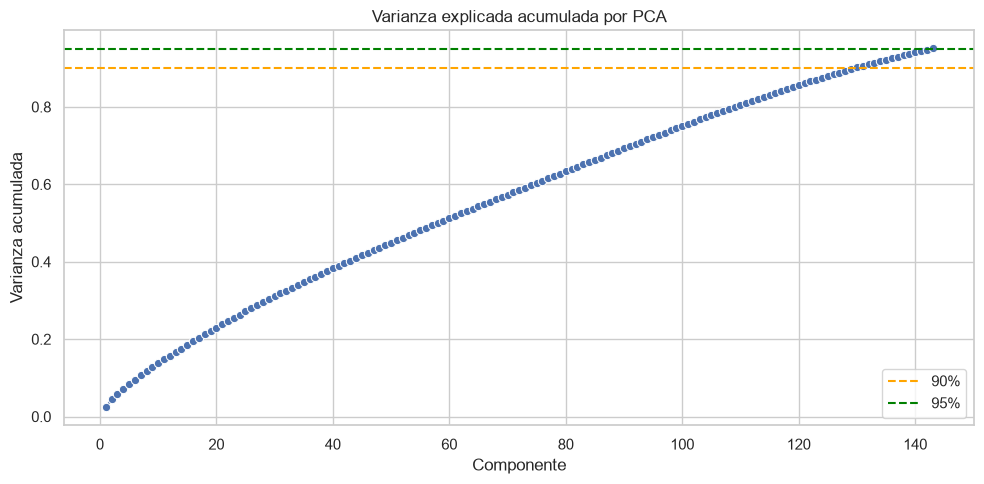

In [26]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=pca_variance, x='Componente', y='Varianza acumulada', marker='o')
plt.axhline(0.90, color='orange', linestyle='--', label='90%')
plt.axhline(0.95, color='green', linestyle='--', label='95%')
plt.title('Varianza explicada acumulada por PCA')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretacion:** PCA reduce dimensionalidad y ayuda a modelos sensibles a escala. Su desventaja es que los componentes pierden interpretacion directa frente a las variables originales.


## 3.5 Modelado

Se entrenan los mismos tres algoritmos en los dos escenarios, para obtener seis experimentos.


In [27]:
model_descriptions = pd.DataFrame({
    'Modelo': ['Ridge', 'HistGradientBoostingRegressor', 'MLPRegressor'],
    'Funcionamiento': [
        'Regresion lineal regularizada para reducir coeficientes extremos.',
        'Ensamble de arboles secuenciales que corrige errores del modelo anterior.',
        'Red neuronal multicapa que aprende relaciones no lineales.'
    ],
    'Parametros principales': [
        'alpha=0.1',
        'max_iter=180, learning_rate=0.05, l2_regularization=0.1',
        'hidden_layer_sizes=(24,), alpha=0.01, max_iter=120'
    ],
    'Justificacion': [
        'Base interpretable y rapida.',
        'Modelo no lineal robusto para datos tabulares.',
        'Cumple el requisito de red neuronal.'
    ],
    'Ventajas y limitaciones': [
        'Rapido, pero puede fallar con relaciones muy no lineales.',
        'Buen desempeno, pero menos interpretable que Ridge.',
        'Flexible, pero sensible al escalado y a hiperparametros.'
    ]
})
model_descriptions


,Modelo,Funcionamiento,Parametros principales,Justificacion,Ventajas y limitaciones
0,Ridge,Regresion lineal regularizada para reducir coe...,alpha=0.1,Base interpretable y rapida.,"Rapido, pero puede fallar con relaciones muy n..."
1,HistGradientBoostingRegressor,Ensamble de arboles secuenciales que corrige e...,"max_iter=180, learning_rate=0.05, l2_regulariz...",Modelo no lineal robusto para datos tabulares.,"Buen desempeno, pero menos interpretable que R..."
2,MLPRegressor,Red neuronal multicapa que aprende relaciones ...,"hidden_layer_sizes=(24,), alpha=0.01, max_iter...",Cumple el requisito de red neuronal.,"Flexible, pero sensible al escalado y a hiperp..."


In [28]:
model_configs = {
    'Ridge': Ridge(alpha=0.1),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.05,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ),
    'MLPRegressor': MLPRegressor(
        hidden_layer_sizes=(24,),
        alpha=0.01,
        max_iter=120,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

def make_model_pipeline(model, features, use_pca=False):
    steps = [
        ('preprocessor', make_preprocessor(features)),
        ('scaler', StandardScaler())
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)))
    steps.append(('model', clone(model)))
    return Pipeline(steps)

pipeline_summary = pd.DataFrame({
    'Escenario': ['Caracteristicas seleccionadas', 'PCA'],
    'Variables de entrada': [', '.join(selected_features), ', '.join(model_features)],
    'Transformaciones': [
        'Imputacion, OneHotEncoder, StandardScaler y modelo.',
        'Imputacion, OneHotEncoder, StandardScaler, PCA y modelo.'
    ]
})
pipeline_summary


,Escenario,Variables de entrada,Transformaciones
0,Caracteristicas seleccionadas,"NA_Sales, EU_Sales, JP_Sales, Other_Sales, Cri...","Imputacion, OneHotEncoder, StandardScaler y mo..."
1,PCA,"Platform, Year_of_Release, Genre, Publisher, N...","Imputacion, OneHotEncoder, StandardScaler, PCA..."


**Hiperparametros:** se usan configuraciones moderadas para evitar sobreajuste y mantener tiempos razonables. No se usa el conjunto de prueba para elegirlos.


## 3.6 Evaluacion y comparacion de los seis experimentos

La evaluacion se realiza con `KFold(n_splits=7, shuffle=True, random_state=42)`.


In [29]:
cv = KFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
scoring = {'r2': 'r2', 'mae': 'neg_mean_absolute_error'}

experiments = [
    ('Caracteristicas seleccionadas', selected_features, False),
    ('PCA', model_features, True)
]

cv_rows = []
fold_rows = []

for scenario_name, features, use_pca in experiments:
    X_experiment = X[features]
    for model_name, model in model_configs.items():
        pipeline = make_model_pipeline(model, features, use_pca=use_pca)
        start_time = time.perf_counter()
        scores = cross_validate(
            pipeline,
            X_experiment,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=None
        )
        elapsed_time = time.perf_counter() - start_time
        r2_values = scores['test_r2']
        mae_values = -scores['test_mae']
        
        cv_rows.append({
            'Escenario': scenario_name,
            'Modelo': model_name,
            'R2 medio': r2_values.mean(),
            'Desv. est. R2': r2_values.std(),
            'Varianza R2': r2_values.var(),
            'MAE medio': mae_values.mean(),
            'Desv. est. MAE': mae_values.std(),
            'Varianza MAE': mae_values.var(),
            'Tiempo entrenamiento medio (s)': scores['fit_time'].mean(),
            'Tiempo total (s)': elapsed_time
        })
        
        for fold, (r2_value, mae_value) in enumerate(zip(r2_values, mae_values), start=1):
            fold_rows.append({
                'Escenario': scenario_name,
                'Modelo': model_name,
                'Particion': fold,
                'R2': r2_value,
                'MAE': mae_value
            })

cv_summary = pd.DataFrame(cv_rows)
cv_folds = pd.DataFrame(fold_rows)

cv_summary_rounded = cv_summary.copy()
numeric_result_cols = cv_summary_rounded.select_dtypes(include=np.number).columns
cv_summary_rounded[numeric_result_cols] = cv_summary_rounded[numeric_result_cols].round(4)
cv_summary_rounded


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo entrenamiento medio (s),Tiempo total (s)
0,Caracteristicas seleccionadas,Ridge,1.0000,0.0000,0.0000,0.0029,0.0001,0.0000,0.0271,0.2944
1,Caracteristicas seleccionadas,HistGradientBoosting,0.8936,0.1002,0.0100,0.0521,0.0064,0.0000,0.7007,5.0662
2,Caracteristicas seleccionadas,MLPRegressor,0.9991,0.0008,0.0000,0.0193,0.0055,0.0000,2.7480,19.3215
3,PCA,Ridge,0.9671,0.0253,0.0006,0.1048,0.0056,0.0000,0.4915,3.7028
4,PCA,HistGradientBoosting,0.9088,0.0748,0.0056,0.1570,0.0207,0.0004,3.0032,21.4891
5,PCA,MLPRegressor,0.9865,0.0081,0.0001,0.0765,0.0128,0.0002,7.7578,54.6119


In [30]:
# Tabla de los tres modelos con caracteristicas seleccionadas
selected_results = cv_summary_rounded.query("Escenario == 'Caracteristicas seleccionadas'")
selected_results


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo entrenamiento medio (s),Tiempo total (s)
0,Caracteristicas seleccionadas,Ridge,1.0000,0.0000,0.00,0.0029,0.0001,0.0,0.0271,0.2944
1,Caracteristicas seleccionadas,HistGradientBoosting,0.8936,0.1002,0.01,0.0521,0.0064,0.0,0.7007,5.0662
2,Caracteristicas seleccionadas,MLPRegressor,0.9991,0.0008,0.00,0.0193,0.0055,0.0,2.7480,19.3215


In [31]:
# Tabla de los tres modelos con PCA
pca_results = cv_summary_rounded.query("Escenario == 'PCA'")
pca_results


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo entrenamiento medio (s),Tiempo total (s)
3,PCA,Ridge,0.9671,0.0253,0.0006,0.1048,0.0056,0.0000,0.4915,3.7028
4,PCA,HistGradientBoosting,0.9088,0.0748,0.0056,0.1570,0.0207,0.0004,3.0032,21.4891
5,PCA,MLPRegressor,0.9865,0.0081,0.0001,0.0765,0.0128,0.0002,7.7578,54.6119


In [32]:
# Tabla general de los seis experimentos
general_results = cv_summary_rounded[
    ['Escenario', 'Modelo', 'R2 medio', 'Desv. est. R2', 'Varianza R2',
     'MAE medio', 'Desv. est. MAE', 'Varianza MAE']
]
general_results


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
0,Caracteristicas seleccionadas,Ridge,1.0000,0.0000,0.0000,0.0029,0.0001,0.0000
1,Caracteristicas seleccionadas,HistGradientBoosting,0.8936,0.1002,0.0100,0.0521,0.0064,0.0000
2,Caracteristicas seleccionadas,MLPRegressor,0.9991,0.0008,0.0000,0.0193,0.0055,0.0000
3,PCA,Ridge,0.9671,0.0253,0.0006,0.1048,0.0056,0.0000
4,PCA,HistGradientBoosting,0.9088,0.0748,0.0056,0.1570,0.0207,0.0004
5,PCA,MLPRegressor,0.9865,0.0081,0.0001,0.0765,0.0128,0.0002


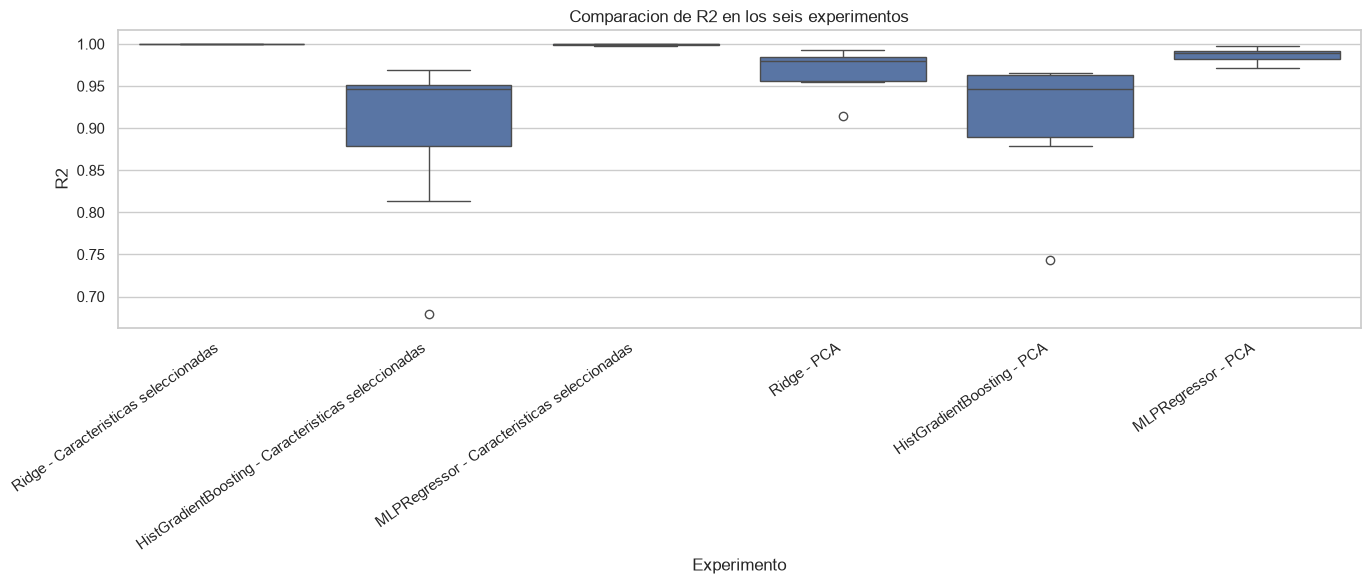

In [33]:
# Boxplot de R2 en las siete particiones
cv_folds['Experimento'] = cv_folds['Modelo'] + ' - ' + cv_folds['Escenario']

plt.figure(figsize=(14, 6))
sns.boxplot(data=cv_folds, x='Experimento', y='R2')
plt.xticks(rotation=35, ha='right')
plt.title('Comparacion de R2 en los seis experimentos')
plt.xlabel('Experimento')
plt.ylabel('R2')
plt.tight_layout()
plt.show()


In [34]:
max_r2 = cv_summary['R2 medio'].max()
candidate_models = cv_summary[cv_summary['R2 medio'] >= max_r2 - 0.005].copy()
best_by_metrics = candidate_models.sort_values(
    ['MAE medio', 'Desv. est. R2', 'Tiempo entrenamiento medio (s)', 'R2 medio'],
    ascending=[True, True, True, False]
).iloc[0]

best_selected = cv_summary.query("Escenario == 'Caracteristicas seleccionadas'").sort_values(
    ['R2 medio', 'MAE medio'], ascending=[False, True]
).iloc[0]

best_pca = cv_summary.query("Escenario == 'PCA'").sort_values(
    ['R2 medio', 'MAE medio'], ascending=[False, True]
).iloc[0]

pd.DataFrame({
    'Resultado': [
        'Mejor con caracteristicas seleccionadas',
        'Mejor con PCA',
        'Mejor general'
    ],
    'Escenario': [
        best_selected['Escenario'],
        best_pca['Escenario'],
        best_by_metrics['Escenario']
    ],
    'Modelo': [
        best_selected['Modelo'],
        best_pca['Modelo'],
        best_by_metrics['Modelo']
    ],
    'R2 medio': [
        round(best_selected['R2 medio'], 4),
        round(best_pca['R2 medio'], 4),
        round(best_by_metrics['R2 medio'], 4)
    ],
    'MAE medio': [
        round(best_selected['MAE medio'], 4),
        round(best_pca['MAE medio'], 4),
        round(best_by_metrics['MAE medio'], 4)
    ]
})


,Resultado,Escenario,Modelo,R2 medio,MAE medio
0,Mejor con caracteristicas seleccionadas,Caracteristicas seleccionadas,Ridge,1.0000,0.0029
1,Mejor con PCA,PCA,MLPRegressor,0.9865,0.0765
2,Mejor general,Caracteristicas seleccionadas,Ridge,1.0000,0.0029


**Seleccion del mejor modelo:** se elige por R2 medio alto, MAE bajo, estabilidad y viabilidad de despliegue. Si hay empate tecnico en R2, se prefiere el modelo mas simple y rapido.


In [35]:
best_fold_detail = cv_folds[
    (cv_folds['Escenario'] == best_by_metrics['Escenario']) &
    (cv_folds['Modelo'] == best_by_metrics['Modelo'])
][['Particion', 'R2', 'MAE']].copy()

summary_rows = pd.DataFrame({
    'Particion': ['Media', 'Desviacion estandar', 'Varianza'],
    'R2': [
        best_fold_detail['R2'].mean(),
        best_fold_detail['R2'].std(),
        best_fold_detail['R2'].var()
    ],
    'MAE': [
        best_fold_detail['MAE'].mean(),
        best_fold_detail['MAE'].std(),
        best_fold_detail['MAE'].var()
    ]
})

best_fold_table = pd.concat([best_fold_detail, summary_rows], ignore_index=True)
best_fold_table[['R2', 'MAE']] = best_fold_table[['R2', 'MAE']].round(4)
best_fold_table


,Particion,R2,MAE
0,1,1.0,0.0029
1,2,1.0,0.0029
2,3,1.0,0.0028
3,4,1.0,0.0031
4,5,1.0,0.0029
5,6,1.0,0.0029
6,7,1.0,0.0028
7,Media,1.0,0.0029
8,Desviacion estandar,0.0,0.0001
9,Varianza,0.0,0.0000


In [36]:
best_partition = best_fold_detail.loc[best_fold_detail['R2'].idxmax()]
worst_partition = best_fold_detail.loc[best_fold_detail['R2'].idxmin()]

pd.DataFrame({
    'Aspecto': [
        'Mejor particion',
        'Peor particion',
        'Diferencia R2',
        'Varianza R2',
        'Lectura'
    ],
    'Valor': [
        int(best_partition['Particion']),
        int(worst_partition['Particion']),
        round(best_partition['R2'] - worst_partition['R2'], 4),
        round(best_fold_detail['R2'].var(), 6),
        'La estabilidad es mayor cuando la varianza es baja y las cajas del boxplot son compactas.'
    ]
})


,Aspecto,Valor
0,Mejor particion,2
1,Peor particion,3
2,Diferencia R2,0.0
3,Varianza R2,0.0
4,Lectura,La estabilidad es mayor cuando la varianza es ...


**Analisis:** si el R2 medio supera 0.80 y la varianza es baja, el modelo cumple el desempeno esperado. El boxplot permite revisar dispersion, mediana y particiones atipicas.


## 3.7 Evaluacion final del mejor modelo

Solo el mejor experimento se evalua con `train_test_split` 80/20.


In [37]:
best_features = selected_features if best_by_metrics['Escenario'] == 'Caracteristicas seleccionadas' else model_features
best_use_pca = best_by_metrics['Escenario'] == 'PCA'
best_model_name = best_by_metrics['Modelo']
best_model = model_configs[best_model_name]

X_best = X[best_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

best_pipeline = make_model_pipeline(best_model, best_features, use_pca=best_use_pca)
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
residuals = y_test - y_pred

final_metrics = pd.DataFrame({
    'Metrica': ['R2 prueba', 'MAE prueba'],
    'Valor': [r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)]
})
final_metrics['Valor'] = final_metrics['Valor'].round(4)
final_metrics


,Metrica,Valor
0,R2 prueba,1.000
1,MAE prueba,0.003


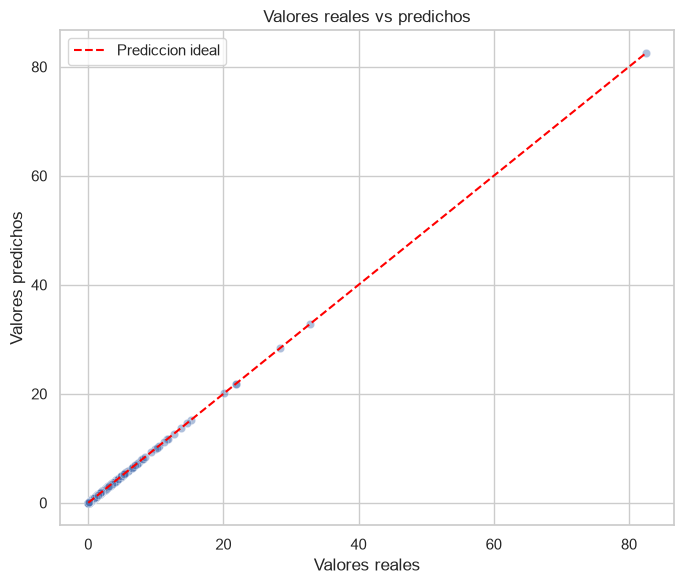

In [38]:
# Grafica de valores reales contra predichos
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', label='Prediccion ideal')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs predichos')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretacion:** mientras mas cerca esten los puntos de la linea roja, menor es el error. Los juegos con ventas muy altas suelen concentrar los mayores errores por ser casos menos frecuentes.


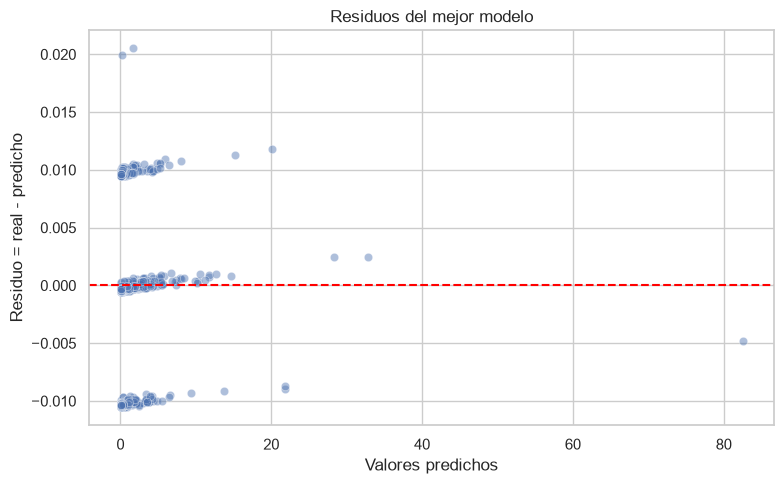

In [39]:
# Grafica de residuos
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.45)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuo = real - predicho')
plt.title('Residuos del mejor modelo')
plt.tight_layout()
plt.show()


**Interpretacion:** residuos dispersos alrededor de cero indican menor sesgo. Si aparecen patrones o mayor dispersion en ventas altas, el modelo tiene mas dificultad con exitos comerciales extremos.


## 3.8 Despliegue del modelo

El modelo final se guarda como pipeline completo para Flask y Render. Incluye imputacion, codificacion, escalado, PCA si aplica y algoritmo de regresion.


In [40]:
deployment_dir = Path('render_app')
deployment_dir.mkdir(exist_ok=True)

final_pipeline = make_model_pipeline(best_model, best_features, use_pca=best_use_pca)
final_pipeline.fit(X_best, y)

model_path = deployment_dir / 'model_pipeline.joblib'
metadata_path = deployment_dir / 'model_metadata.json'
joblib.dump(final_pipeline, model_path)

deployment_metadata = {
    'dataset': DATASET_NAME,
    'target': target,
    'target_unit': 'millones de copias vendidas',
    'scenario': best_by_metrics['Escenario'],
    'model': best_model_name,
    'features': best_features,
    'uses_pca': bool(best_use_pca),
    'render_url': 'https://ps4-global-sales-predictor.onrender.com/',
    'numeric_features': [feature for feature in best_features if feature in numeric_features],
    'categorical_features': [feature for feature in best_features if feature in categorical_features],
    'categories': {
        feature: sorted(model_data[feature].dropna().astype(str).unique().tolist())
        for feature in best_features
        if feature in categorical_features
    }
}

with open(metadata_path, 'w', encoding='utf-8') as file:
    json.dump(deployment_metadata, file, ensure_ascii=False, indent=2)

Path('URL_Render.txt').write_text(deployment_metadata['render_url'], encoding='utf-8')

pd.DataFrame({
    'Archivo generado': [str(model_path), str(metadata_path), 'URL_Render.txt'],
    'Proposito': [
        'Pipeline final entrenado.',
        'Metadatos para formulario y descripcion del modelo.',
        'URL publica de Render.'
    ]
})


,Archivo generado,Proposito
0,render_app\model_pipeline.joblib,Pipeline final entrenado.
1,render_app\model_metadata.json,Metadatos para formulario y descripcion del mo...
2,URL_Render.txt,URL publica de Render.


**Aplicacion Flask:** el formulario debe pedir variables originales, no columnas escaladas, dummies ni componentes principales. Render debe ejecutar el pipeline guardado y mostrar `Global_Sales` en millones de copias.


## 3.9 Conclusiones y reflexion critica

El dataset permitio estudiar ventas globales de videojuegos con variables comerciales, tecnicas y de recepcion. El principal problema de calidad fue la presencia de nulos en puntajes, conteos, desarrollador y clasificacion, por lo que se uso imputacion dentro de pipelines.

La codificacion OneHotEncoder permitio usar variables nominales sin imponer un orden artificial. El escalado fue necesario para Ridge, MLP y PCA, y se aplico dentro del pipeline para evitar fuga de informacion.

La seleccion de caracteristicas combino correlacion, RFE y arboles. Las ventas regionales `NA_Sales`, `EU_Sales`, `JP_Sales` y `Other_Sales` tuvieron relacion fuerte con `Global_Sales`; `Critic_Score` y `Critic_Count` aportaron informacion de recepcion critica.

PCA ayudo a reducir dimensionalidad despues de codificar categorias, pero perdio interpretabilidad porque sus componentes no se leen como variables originales. La seleccion de caracteristicas fue mas facil de explicar.

El mejor modelo se eligio con base en R2 medio, MAE, estabilidad, varianza y boxplot. Si el R2 medio supera 0.80 y la varianza es baja, el modelo cumple el desempeno esperado. Las graficas finales ayudan a ver si los errores aumentan en juegos con ventas extremas.

La principal limitacion es que el modelo no debe interpretarse como prediccion antes del lanzamiento. Usa informacion observada del juego y ventas regionales. En un entorno real, una mala prediccion podria afectar inventario, presupuesto o expectativas comerciales. El estudio podria mejorar con variables de marketing, fecha exacta de lanzamiento, precio, unidades digitales y datos por periodo.

Se publica el mejor pipeline en Render porque permite usar las mismas transformaciones de la libreta en una aplicacion web sencilla.
